# dReeb Tutorial

This notebook is a practical introduction to `dreeb` and `plot_dreeb`.

It demonstrates three common workflows:

1. A torus, using the default first nontrivial diffusion eigenfunction.
2. A hollow cylinder, comparing `diffusion_eigen_index=1` and `diffusion_eigen_index=2` on the same point cloud.
3. A sun-shaped point cloud, showing how to extract point supports for selected nodes, edges, and branch trajectories.

Throughout, we also visualize the simplified graph, look at persistence diagrams, and use both 3D and 2D views when they help readability.

## Imports

In [25]:
import math
import sys
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Make the local repo importable before the package is published.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from dreeb import dreeb, plot_dreeb


## Helpers

These helpers keep the tutorial cells focused on the dReeb workflow rather than plotting boilerplate.

In [26]:
def sample_torus(n=1800, R=2.0, r=0.7, noise=0.04, seed=0):
    rng = np.random.default_rng(seed)
    u = rng.uniform(0.0, 2.0 * np.pi, size=n)
    v = rng.uniform(0.0, 2.0 * np.pi, size=n)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    X = np.column_stack([x, y, z])
    X += rng.normal(scale=noise, size=X.shape)
    return X


def sample_hollow_cylinder(n=1600, radius=1.0, height=3.0, noise=0.03, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    z = rng.uniform(-0.5 * height, 0.5 * height, size=n)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    X = np.column_stack([x, y, z])
    X += rng.normal(scale=noise, size=X.shape)
    return X


def sample_sun_point_cloud(
    ring_points=700,
    branches=8,
    branch_points=140,
    ring_radius=1.0,
    branch_length=1.4,
    noise=0.035,
    seed=0,
):
    rng = np.random.default_rng(seed)

    theta = rng.uniform(0.0, 2.0 * np.pi, size=ring_points)
    ring = np.column_stack([
        ring_radius * np.cos(theta),
        ring_radius * np.sin(theta),
    ])
    ring += rng.normal(scale=noise, size=ring.shape)

    branch_clouds = []
    branch_angles = np.linspace(0.0, 2.0 * np.pi, num=branches, endpoint=False)
    for angle in branch_angles:
        direction = np.array([math.cos(angle), math.sin(angle)])
        normal = np.array([-direction[1], direction[0]])
        t = rng.uniform(0.0, branch_length, size=branch_points)
        anchor = ring_radius * direction
        pts = anchor + t[:, None] * direction[None, :]
        pts += rng.normal(scale=noise, size=pts.shape)
        pts += rng.normal(scale=0.6 * noise, size=(branch_points, 1)) * normal[None, :]
        branch_clouds.append(pts)

    return np.vstack([ring] + branch_clouds)


def project_pca_2d(X):
    return PCA(n_components=2, random_state=0).fit_transform(X)


def dreeb_with_plotting(X, **kwargs):
    options = dict(
        return_raw=True,
        return_intermediates=True,
        return_simp_persistence=True,
    )
    options.update(kwargs)
    return dreeb(X, **options)


def summarize_result(result, title=None):
    simp = result["simplified"]
    persistence = simp.get("persistence", {})
    if title:
        print(title)
        print("-" * len(title))
    print("nodes:", len(simp["nodes"]))
    print("edges:", len(simp["edges"]))
    print("beta1:", simp["beta1"])
    print("components:", simp["comp_count"])
    if "h1" in persistence:
        print("H1 count:", persistence["h1"].shape[0])
    print("selected diffusion eigenvalues:", result["intermediates"].get("diffusion_eigenvalues"))


def plot_filter_values(X, filter_values, title, elev=20, azim=-55):
    X = np.asarray(X)
    fig = plt.figure(figsize=(7, 6))
    if X.shape[1] == 3:
        ax = fig.add_subplot(111, projection="3d")
        sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=filter_values, cmap="viridis", s=8, alpha=0.85)
        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect(np.ptp(X, axis=0) + 1e-12)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    else:
        ax = fig.add_subplot(111)
        sc = ax.scatter(X[:, 0], X[:, 1], c=filter_values, cmap="viridis", s=8, alpha=0.85)
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.08, label="filter value")
    plt.show()


def plot_persistence_diagram(persistence, title="Persistence Diagram"):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    finite_vals = []
    for key in ("h0", "h1"):
        arr = persistence[key]
        if arr.size > 0:
            finite_vals.extend(arr[np.isfinite(arr)].ravel().tolist())

    max_finite = max(finite_vals) if finite_vals else 1.0
    inf_y = max_finite * 1.1 + 1e-6

    h0 = persistence["h0"]
    if h0.size > 0:
        ax.scatter(h0[:, 0], h0[:, 1], color="tab:blue", s=40, label="H0")

    h1 = persistence["h1"]
    if h1.size > 0:
        y = np.where(np.isfinite(h1[:, 1]), h1[:, 1], inf_y)
        ax.scatter(h1[:, 0], y, color="crimson", marker="x", s=55, label="H1")

    h0e = persistence["h0_essential"]
    if h0e.size > 0:
        y = np.where(np.isfinite(h0e[:, 1]), h0e[:, 1], inf_y)
        ax.scatter(h0e[:, 0], y, color="tab:green", marker="^", s=48, label="H0 essential")

    lo = 0.0
    hi = max(max_finite, inf_y)
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", linewidth=1.0)
    ax.axhline(inf_y, linestyle=":", color="gray", linewidth=1.0)
    ax.text(lo, inf_y, "inf", va="bottom", ha="left", fontsize=9)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, inf_y * 1.02)
    ax.set_title(title)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.legend()
    ax.set_aspect("equal", adjustable="box")
    plt.show()


def plot_overlay(result, pts, title, label_degree=True):
    fig, _ = plot_dreeb(
        pts=pts,
        simp_edges=result["simplified"]["edges"],
        keep_ids=result["simplified"]["keep_ids"],
        reeb_nodes=result["raw"]["nodes"],
        step_vertices=result["intermediates"]["step_vertices"],
        step_comp_ids=result["intermediates"]["step_comp_ids"],
        uniq_v=result["intermediates"]["prep_state"]["uniq_v"],
        color_cycles=True,
        label_degree=label_degree,
        figsize=(8, 7),
    )
    if fig.axes:
        fig.axes[0].set_title(title)
    plt.show()


def simplified_degrees(num_nodes, edges):
    deg = np.zeros(num_nodes, dtype=int)
    for u, v in edges:
        deg[int(u)] += 1
        deg[int(v)] += 1
    return deg


def build_simple_adjacency(num_nodes, edges):
    adj = [[] for _ in range(num_nodes)]
    for eid, (u, v) in enumerate(edges):
        u = int(u)
        v = int(v)
        adj[u].append((v, eid))
        if u != v:
            adj[v].append((u, eid))
    return adj


def edge_path_between_nodes(num_nodes, edges, start, goal):
    adj = build_simple_adjacency(num_nodes, edges)
    parent = {int(start): None}
    parent_edge = {}
    q = deque([int(start)])
    while q:
        u = q.popleft()
        if u == int(goal):
            break
        for v, eid in adj[u]:
            if v not in parent:
                parent[v] = u
                parent_edge[v] = eid
                q.append(v)
    if int(goal) not in parent:
        return []
    path_edges = []
    cur = int(goal)
    while parent[cur] is not None:
        path_edges.append(parent_edge[cur])
        cur = parent[cur]
    path_edges.reverse()
    return path_edges


def highlight_points(pts, selected, title, selected_color="crimson", base_alpha=0.18):
    pts = np.asarray(pts)
    selected = np.asarray(selected, dtype=int)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(pts[:, 0], pts[:, 1], s=8, color="lightgray", alpha=base_alpha)
    if selected.size > 0:
        ax.scatter(pts[selected, 0], pts[selected, 1], s=12, color=selected_color, alpha=0.9)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    plt.show()


## 1. Torus: the default workflow

We start with a torus because it gives a clean first example: one connected component and one essential loop.

In [27]:
X_torus = sample_torus(seed=7)

# First contact with the API: just pass the data and a neighborhood size.
torus_basic = dreeb(X_torus, k=30)

print("Default dReeb call")
print("------------------")
print("primary_graph:", torus_basic["primary_graph"])
print("nodes:", len(torus_basic["simplified"]["nodes"]))
print("edges:", len(torus_basic["simplified"]["edges"]))
print("beta1:", torus_basic["simplified"]["beta1"])
print("components:", torus_basic["simplified"]["comp_count"])


Default dReeb call
------------------
primary_graph: simplified
nodes: 4
edges: 4
beta1: 1
components: 1


Torus with plotting and persistence outputs
-------------------------------------------
nodes: 4
edges: 4
beta1: 1
components: 1
H1 count: 1
selected diffusion eigenvalues: [0.99217143]


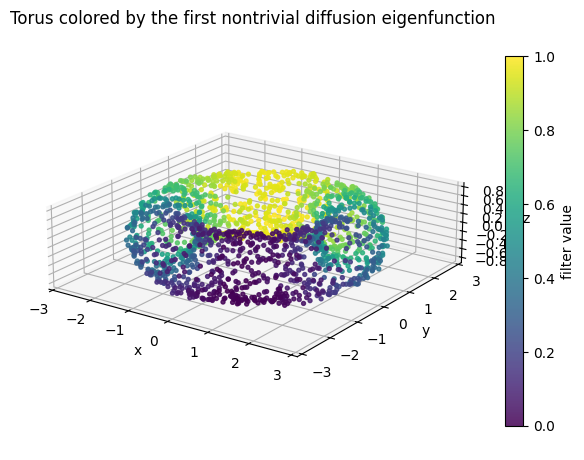

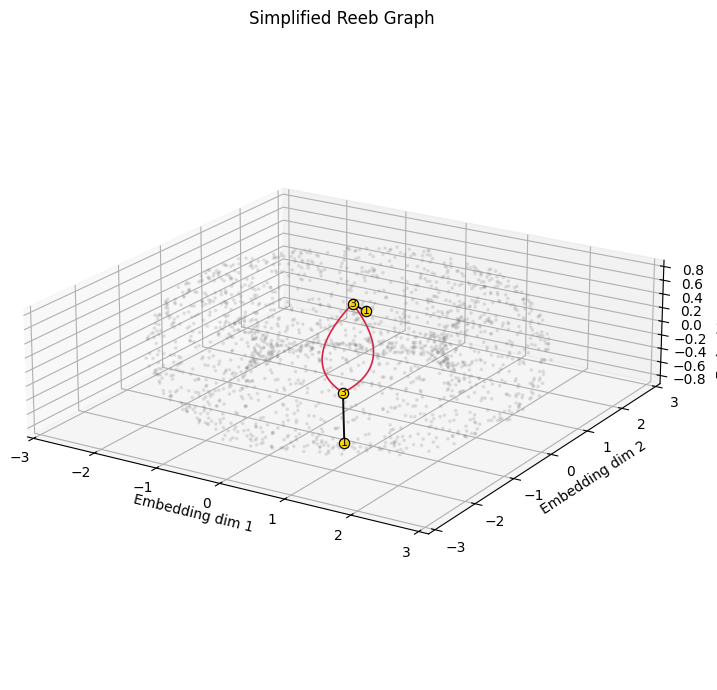

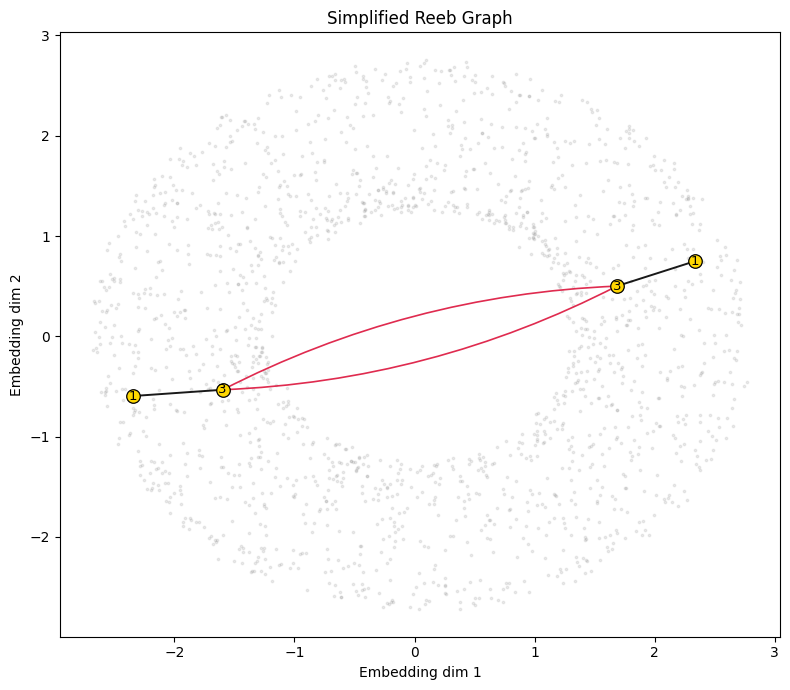

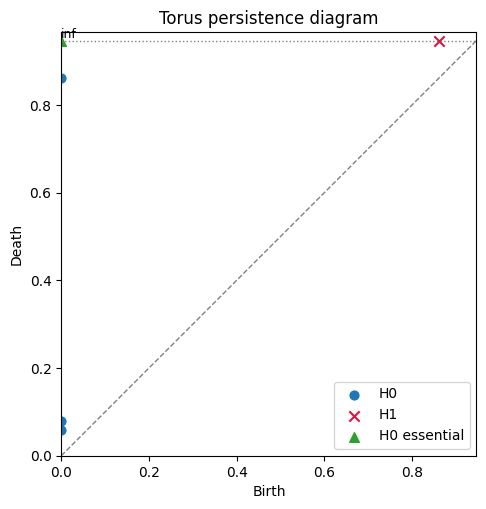

In [28]:
torus_2d = project_pca_2d(X_torus)
torus_result = dreeb_with_plotting(X_torus, k=30)

summarize_result(torus_result, title="Torus with plotting and persistence outputs")

plot_filter_values(
    X_torus,
    torus_result["intermediates"]["filter_values"],
    title="Torus colored by the first nontrivial diffusion eigenfunction",
)

plot_overlay(torus_result, X_torus, title="Simplified dReeb graph on the torus (3D overlay)")
plot_overlay(torus_result, torus_2d, title="Simplified dReeb graph on the torus (2D PCA overlay)")
plot_persistence_diagram(torus_result["simplified"]["persistence"], title="Torus persistence diagram")


## 2. Hollow Cylinder: comparing diffusion eigenfunctions

The geometry stays fixed, but the scalar filter changes when we move from the first to the second nontrivial diffusion eigenfunction. This is the main user-facing parameter for changing the lens.

In [29]:
X_cylinder = sample_hollow_cylinder(seed=11)
cylinder_2d = project_pca_2d(X_cylinder)

cylinder_result_1 = dreeb_with_plotting(X_cylinder, k=30, diffusion_eigen_index=1)
cylinder_result_2 = dreeb_with_plotting(X_cylinder, k=30, diffusion_eigen_index=2)

summarize_result(cylinder_result_1, title="Cylinder with diffusion_eigen_index=1")
print()
summarize_result(cylinder_result_2, title="Cylinder with diffusion_eigen_index=2")


Cylinder with diffusion_eigen_index=1
-------------------------------------
nodes: 6
edges: 7
beta1: 2
components: 1
H1 count: 2
selected diffusion eigenvalues: [0.98712398]

Cylinder with diffusion_eigen_index=2
-------------------------------------
nodes: 4
edges: 4
beta1: 1
components: 1
H1 count: 1
selected diffusion eigenvalues: [0.98669439]


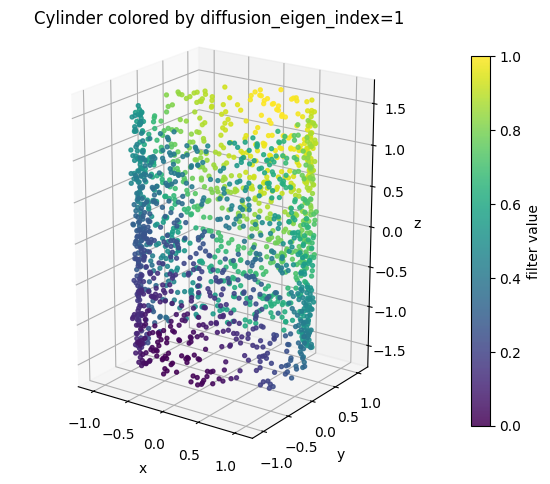

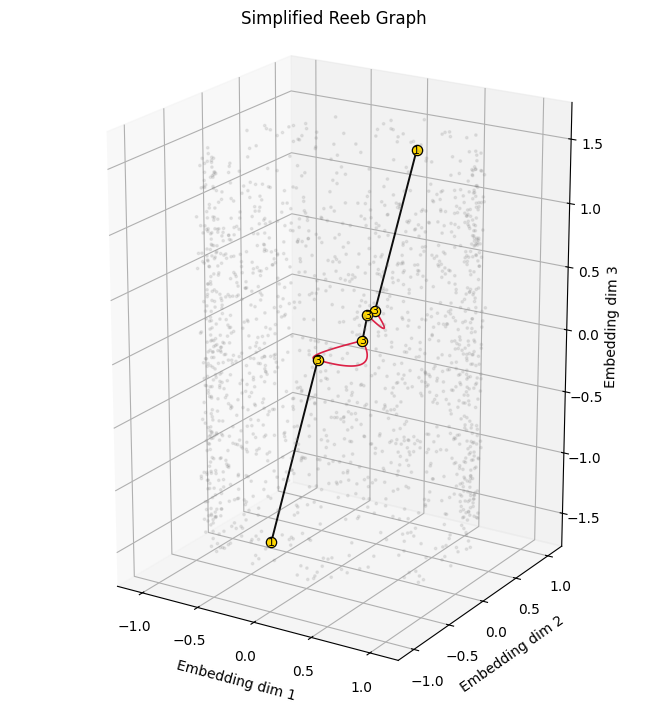

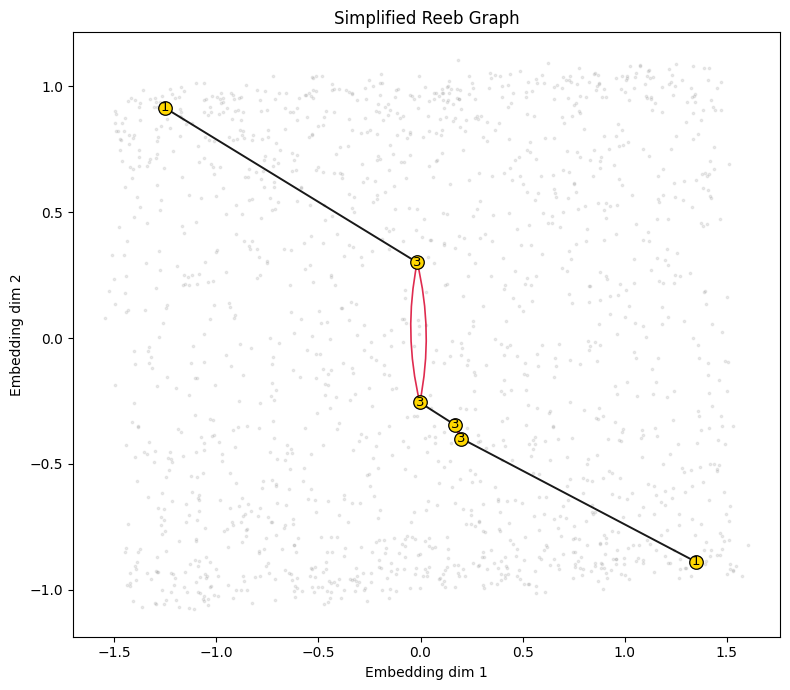

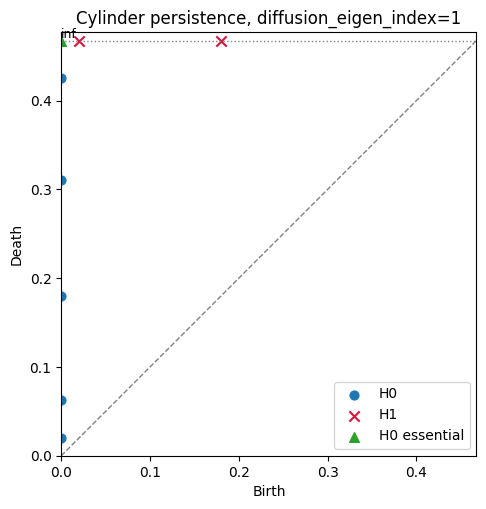

In [30]:
plot_filter_values(
    X_cylinder,
    cylinder_result_1["intermediates"]["filter_values"],
    title="Cylinder colored by diffusion_eigen_index=1",
)
plot_overlay(cylinder_result_1, X_cylinder, title="Cylinder overlay, diffusion_eigen_index=1 (3D)")
plot_overlay(cylinder_result_1, cylinder_2d, title="Cylinder overlay, diffusion_eigen_index=1 (2D PCA)")
plot_persistence_diagram(
    cylinder_result_1["simplified"]["persistence"],
    title="Cylinder persistence, diffusion_eigen_index=1",
)


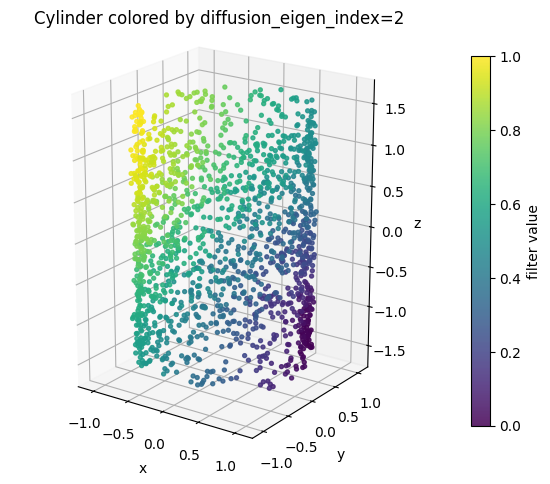

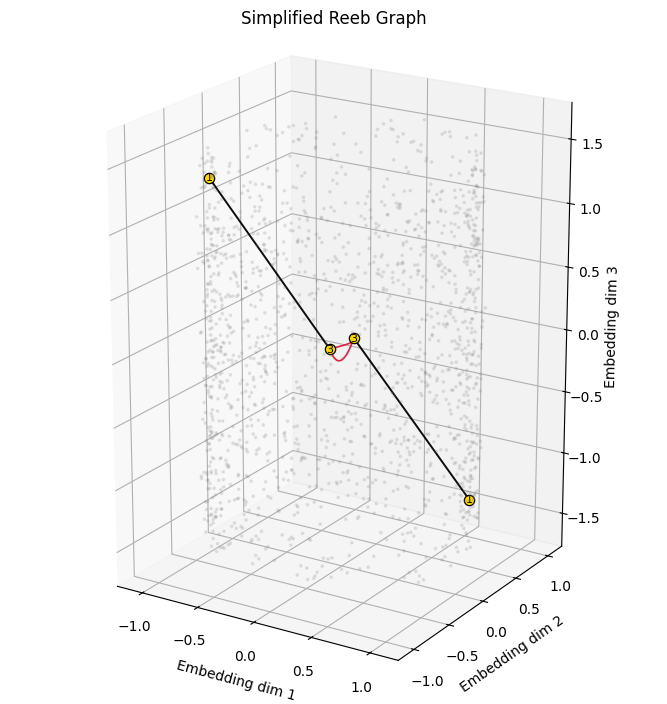

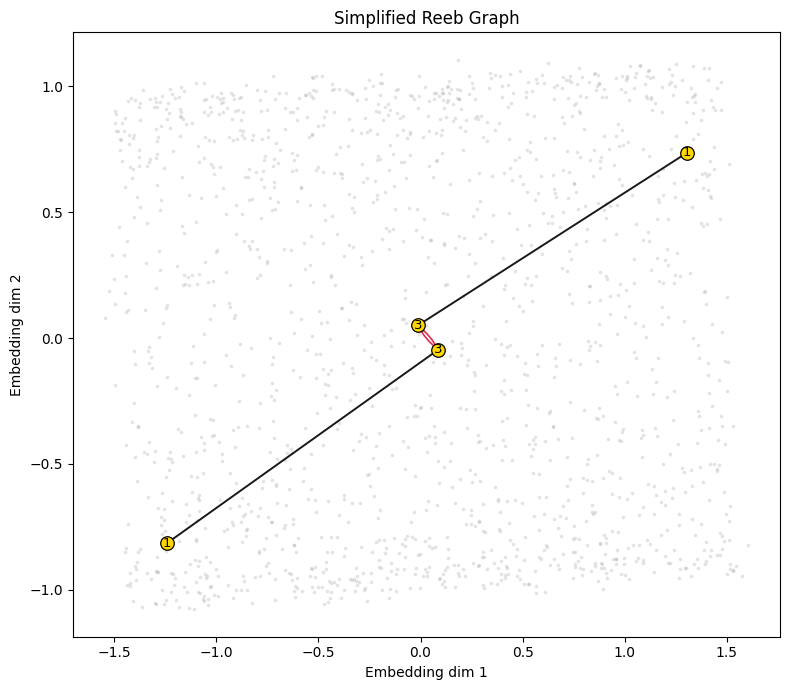

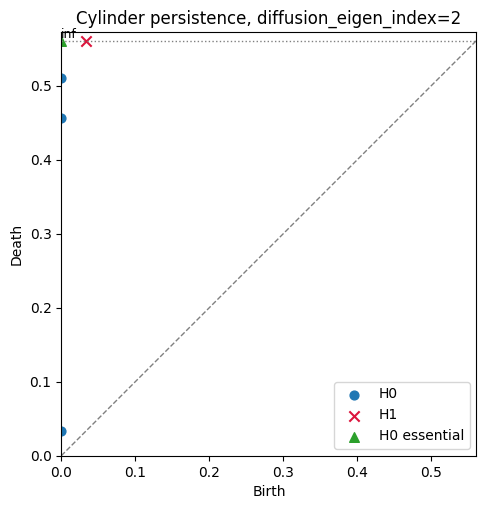

In [31]:
plot_filter_values(
    X_cylinder,
    cylinder_result_2["intermediates"]["filter_values"],
    title="Cylinder colored by diffusion_eigen_index=2",
)
plot_overlay(cylinder_result_2, X_cylinder, title="Cylinder overlay, diffusion_eigen_index=2 (3D)")
plot_overlay(cylinder_result_2, cylinder_2d, title="Cylinder overlay, diffusion_eigen_index=2 (2D PCA)")
plot_persistence_diagram(
    cylinder_result_2["simplified"]["persistence"],
    title="Cylinder persistence, diffusion_eigen_index=2",
)


## 3. Sun Point Cloud: node and edge support extraction

For the final example, we ask for point and edge assignments. This makes it possible to recover the points supporting a selected node, a selected edge, or an entire branch-like trajectory through the simplified graph.

In [32]:
X_sun = sample_sun_point_cloud(seed=5)

sun_result = dreeb_with_plotting(
    X_sun,
    k=30,
    diffusion_eigen_index=1,
    return_point_assignment=True,
    return_edge_assignment=True,
)

summarize_result(sun_result, title="Sun point cloud with point and edge assignments")


Sun point cloud with point and edge assignments
-----------------------------------------------
nodes: 16
edges: 16
beta1: 1
components: 1
H1 count: 1
selected diffusion eigenvalues: [0.99922593]


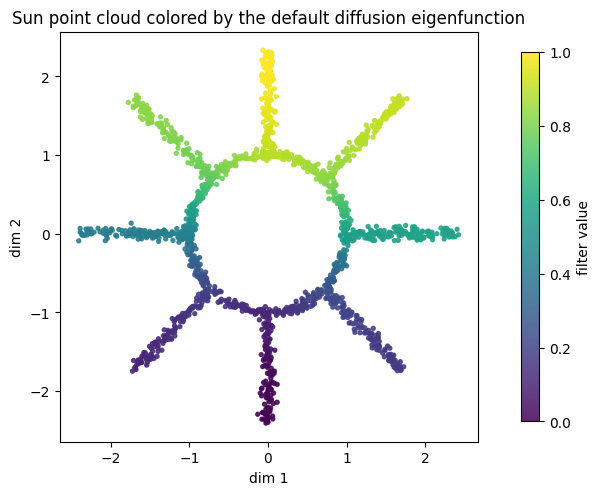

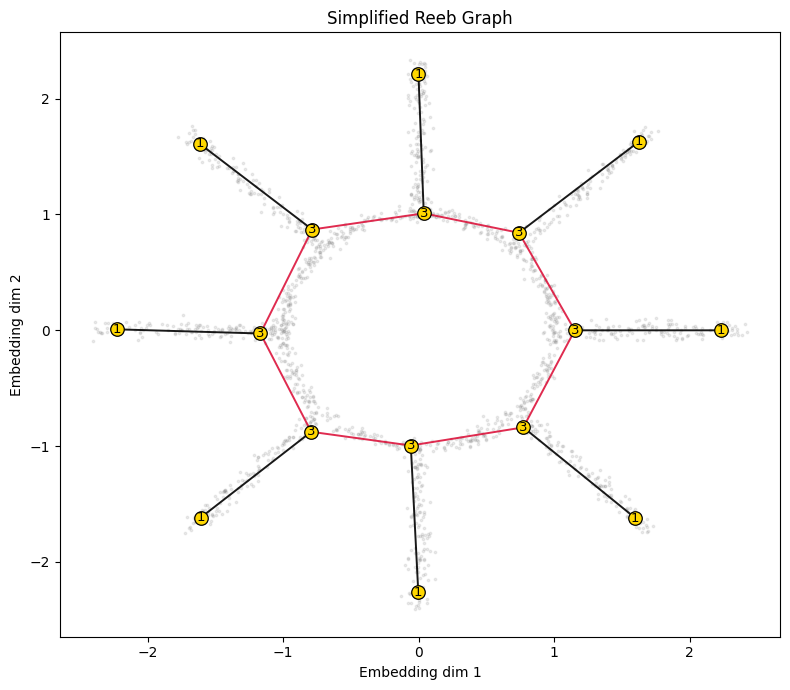

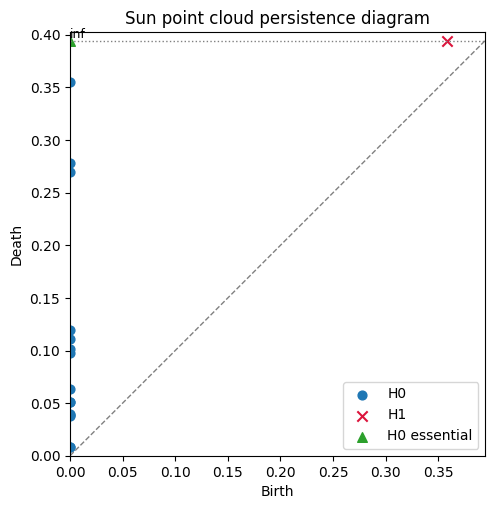

In [33]:
plot_filter_values(
    X_sun,
    sun_result["intermediates"]["filter_values"],
    title="Sun point cloud colored by the default diffusion eigenfunction",
)
plot_overlay(sun_result, X_sun, title="Sun point cloud with simplified dReeb overlay", label_degree=True)
plot_persistence_diagram(sun_result["simplified"]["persistence"], title="Sun point cloud persistence diagram")


In [34]:
sun_simplified = sun_result["simplified"]
sun_edges = sun_simplified["edges"]
sun_node_support_points = sun_simplified["node_support_points"]
sun_edge_points = sun_simplified["edge_points"]

num_nodes = len(sun_simplified["nodes"])
deg = simplified_degrees(num_nodes, sun_edges)

center_node = int(np.argmax(deg))
leaf_nodes = np.flatnonzero(deg == 1)
leaf_node = int(max(leaf_nodes, key=lambda idx: len(sun_node_support_points[int(idx)]))) if len(leaf_nodes) else int(np.argmin(deg))
trajectory_edge_ids = edge_path_between_nodes(num_nodes, sun_edges, center_node, leaf_node)
trajectory_points = np.unique(np.concatenate([sun_edge_points[eid] for eid in trajectory_edge_ids])) if trajectory_edge_ids else np.empty(0, dtype=int)

print("center_node:", center_node, "degree:", deg[center_node], "support points:", len(sun_node_support_points[center_node]))
print("leaf_node:", leaf_node, "degree:", deg[leaf_node], "support points:", len(sun_node_support_points[leaf_node]))
print("trajectory_edge_ids:", trajectory_edge_ids)
print("trajectory_points:", len(trajectory_points))


center_node: 2 degree: 3 points: 115
leaf_node: 6 degree: 1 points: 122
trajectory_edge_ids: [3, 4, 7]
trajectory_points: 257


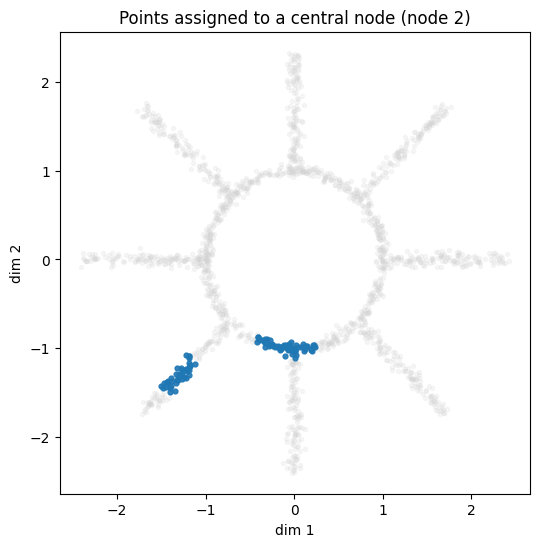

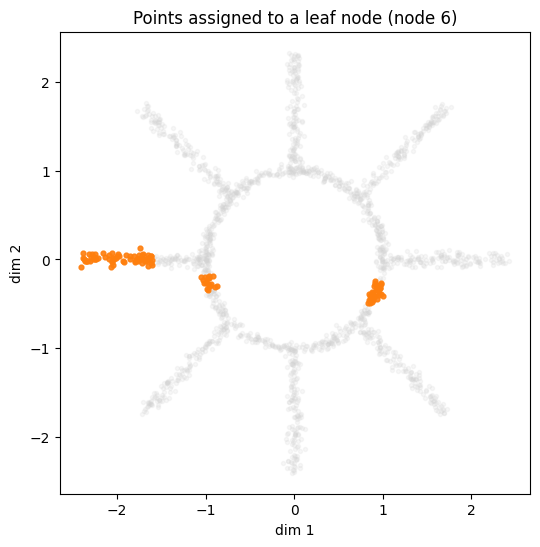

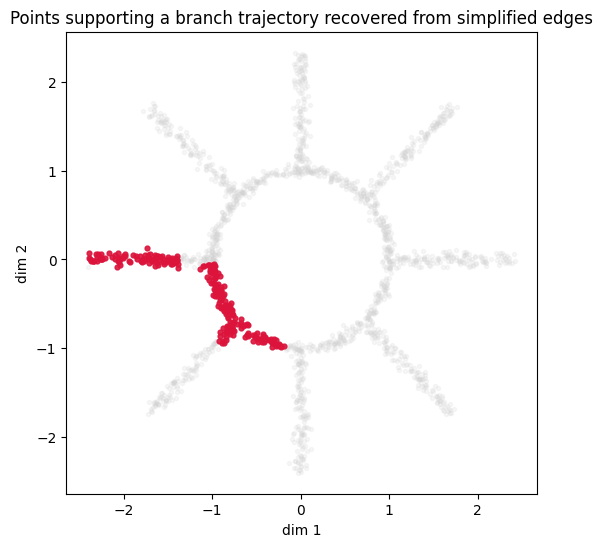

In [35]:
highlight_points(
    X_sun,
    sun_node_support_points[center_node],
    title=f"Intrinsic support points for a central node (node {center_node})",
    selected_color="tab:blue",
)

highlight_points(
    X_sun,
    sun_node_support_points[leaf_node],
    title=f"Intrinsic support points for a leaf node (node {leaf_node})",
    selected_color="tab:orange",
)

highlight_points(
    X_sun,
    trajectory_points,
    title="Points supporting a branch trajectory recovered from simplified edges",
    selected_color="crimson",
)


## Takeaways

- `dreeb(X)` gives a compact default topological summary.
- `diffusion_eigen_index` changes the scalar lens while keeping the rest of the pipeline fixed.
- `plot_dreeb` can overlay the simplified graph on either a 3D point cloud or a 2D projection.
- `return_simp_persistence=True` exposes graph persistence directly from the simplified output.
- `return_point_assignment=True` and `return_edge_assignment=True` make it possible to pull back graph structure to the original points.

A good default workflow is:

1. Start with the default filter.
2. Inspect the simplified graph and persistence diagram.
3. If the geometry suggests another meaningful axis, rerun with a different `diffusion_eigen_index`.
4. Ask for point and edge assignments when you want interpretable supports or trajectories in the original data.